# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** → dense region  
2. **Border point** → not dense itself, but within `eps` of a core point  
3. **Noise point** → neither core nor border (isolated points)
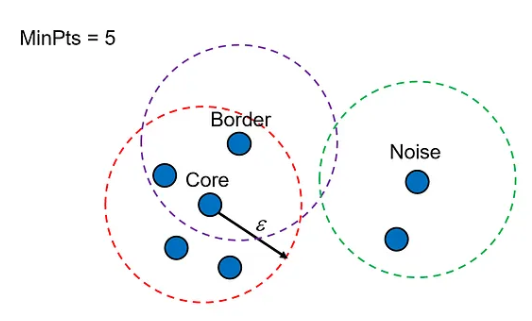

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` → more points are labeled as **noise**  

- Larger `eps` → clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller → clusters form more easily, fewer noise points

- Larger → only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered “neighbors”

**Default:** `euclidean`

**Common options:**  
  - `euclidean` → straight-line distance; most common for numeric features  
  - `manhattan` → sum of absolute differences; robust to outliers  
  - `cosine` → measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

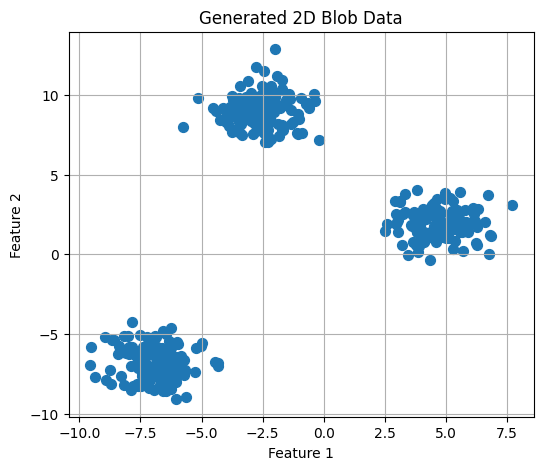

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [ ]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

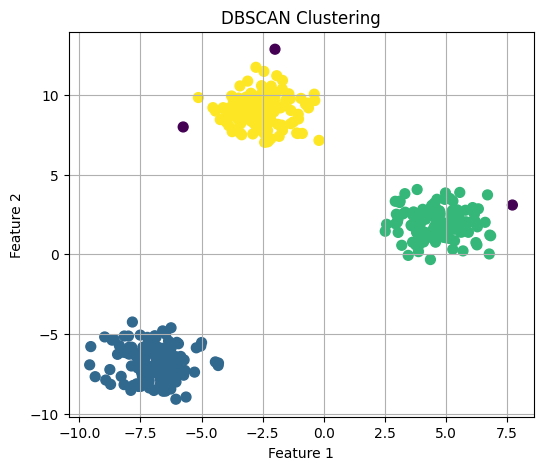

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [ ]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

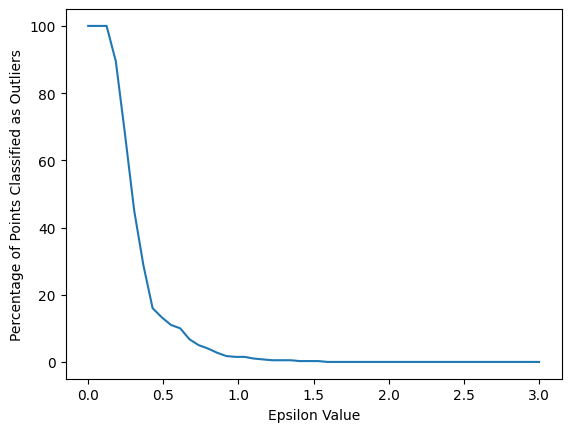

In [ ]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

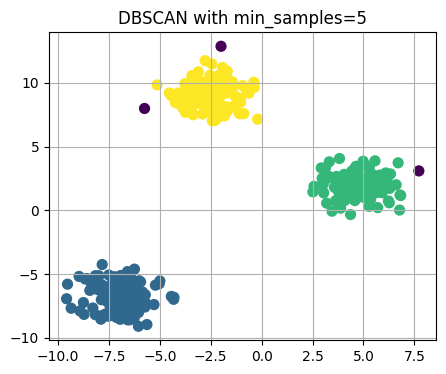

min_samples=5 → Silhouette Score: 0.848


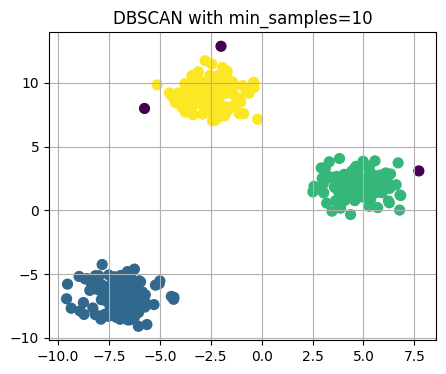

min_samples=10 → Silhouette Score: 0.848


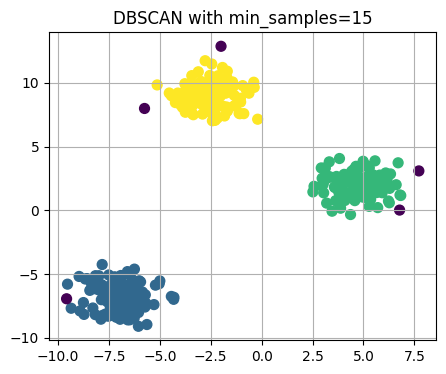

min_samples=15 → Silhouette Score: 0.849


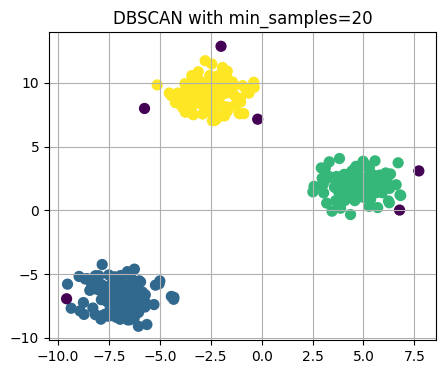

min_samples=20 → Silhouette Score: 0.850


In [ ]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} → Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CC GENERAL.csv to CC GENERAL (1).csv


Saving CC GENERAL.csv to CC GENERAL (6).csv
Using file: CC GENERAL (6).csv
Numeric Features: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Categorical Features: ['CUST_ID']

Numeric Features Distribution:
                                   count         mean          std        min  \
BALANCE                           8950.0  1564.474828  2081.531879   0.000000   
BALANCE_FREQUENCY                 8950.0     0.877271     0.236904   0.000000   
PURCHASES                         8950.0  1003.204834  2136.634782   0.000000   
ONEOFF_PURCHASES                  8950.0   592.437371  1659.887917   0.000000   
INSTALLMENTS_PURCHASES            8950.0   411.067645   904.338115   0.000000   
CASH_ADVANCE     

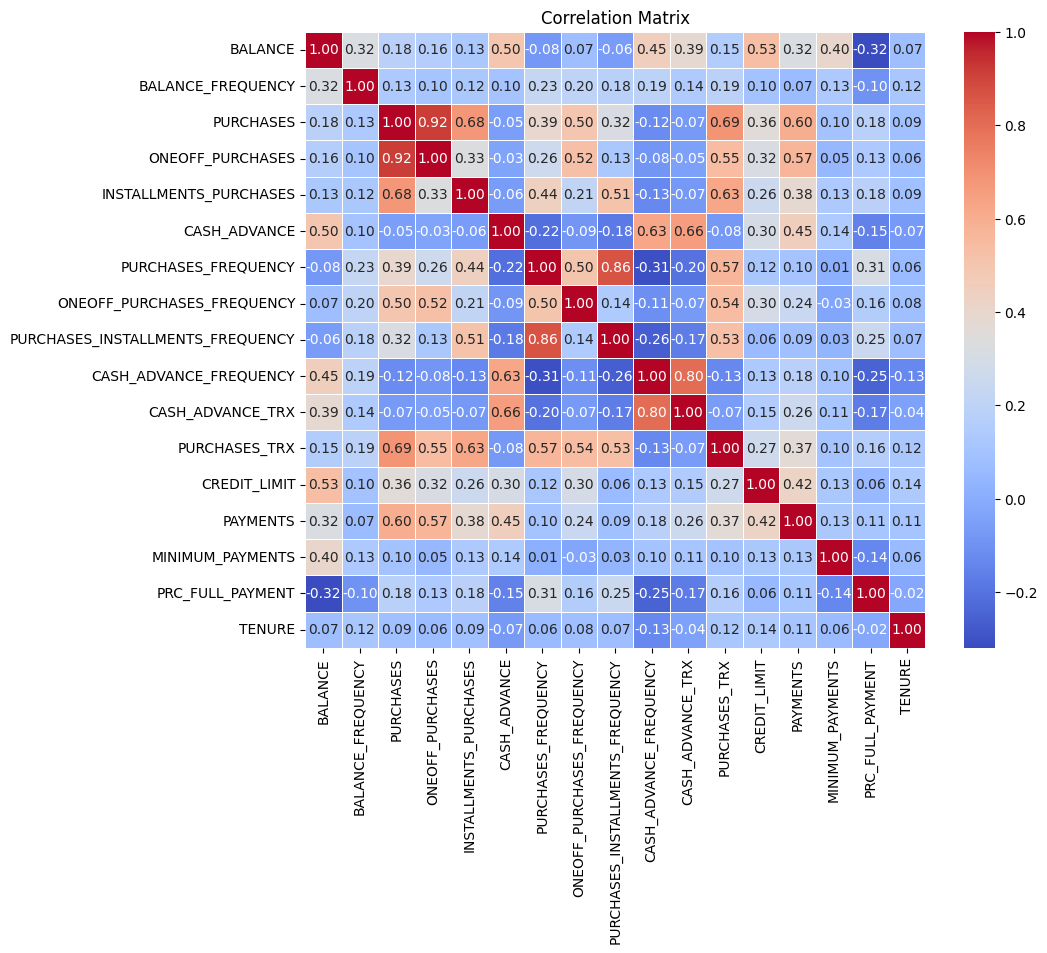

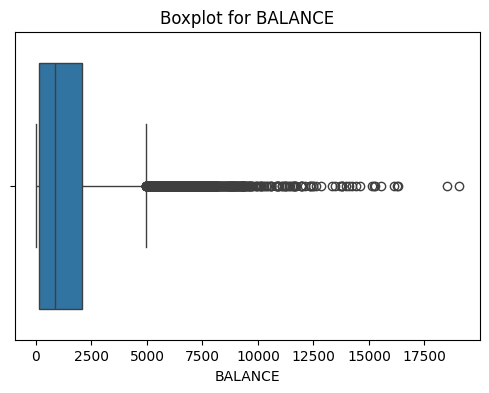

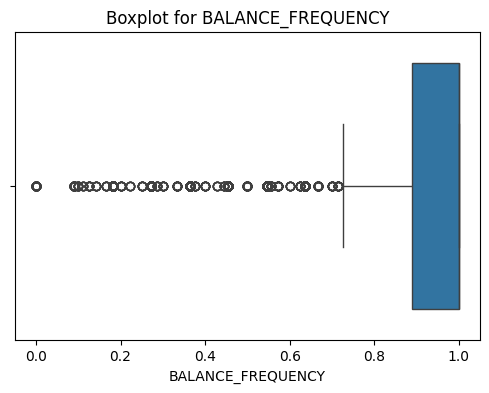

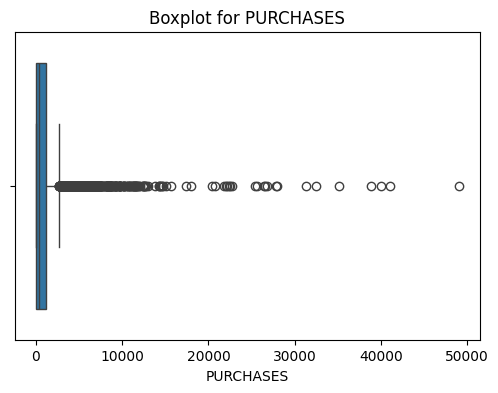

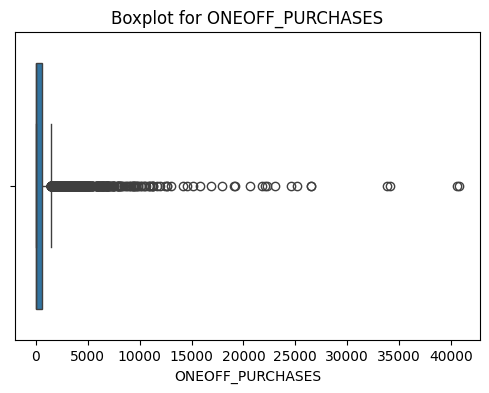

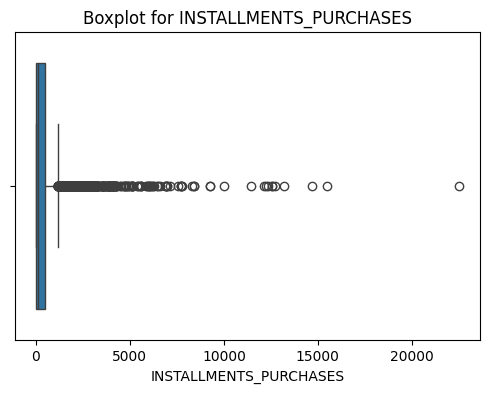

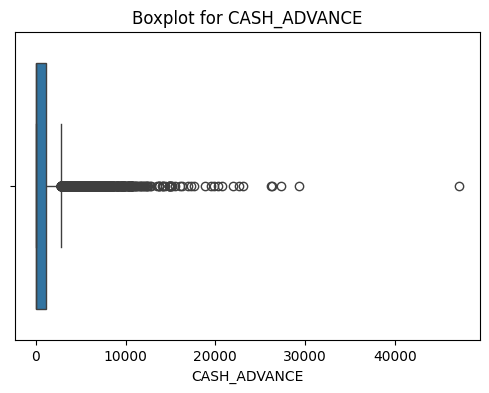

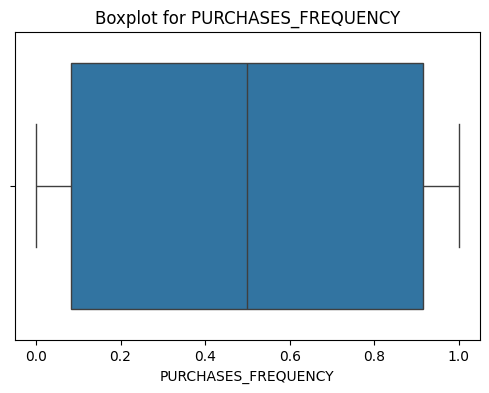

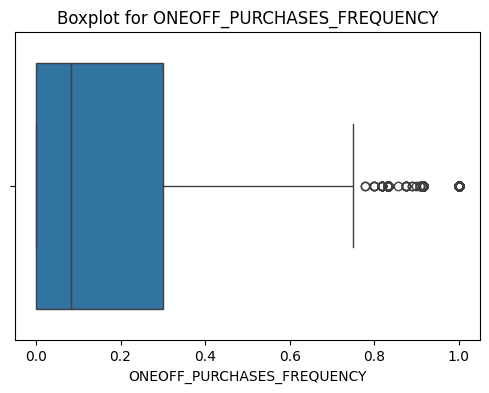

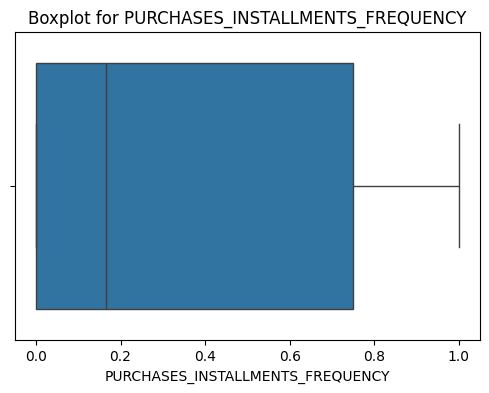

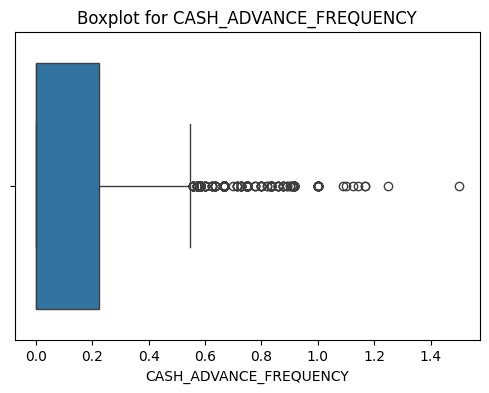

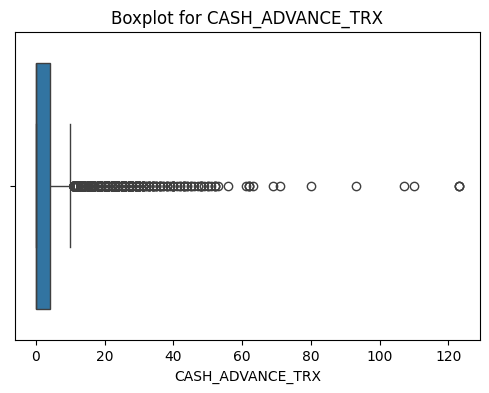

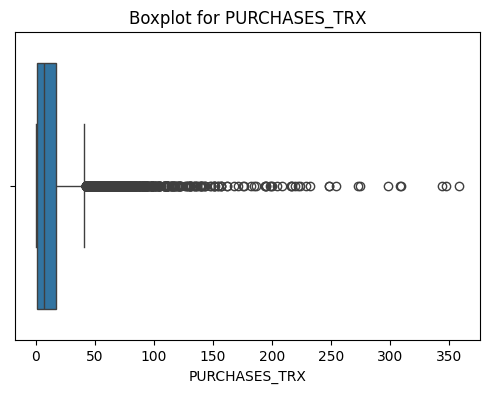

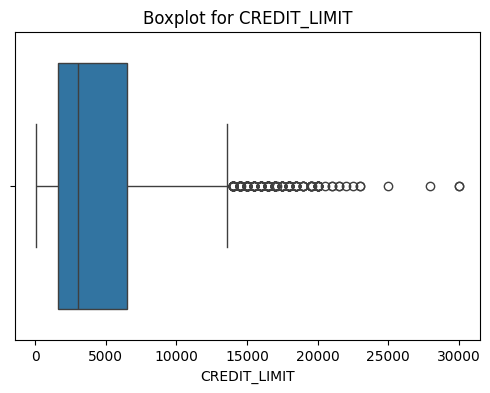

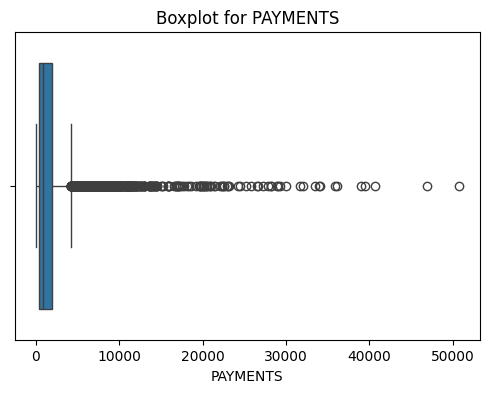

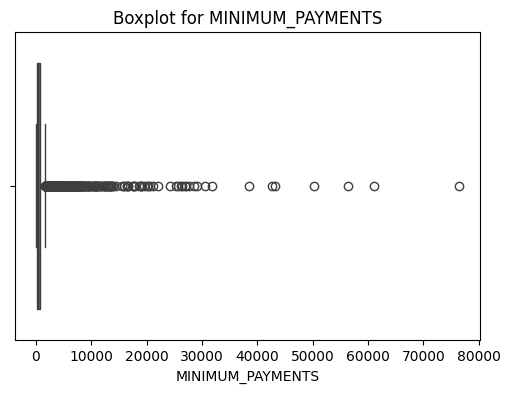

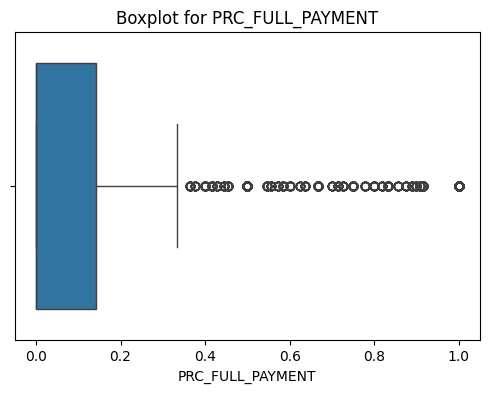

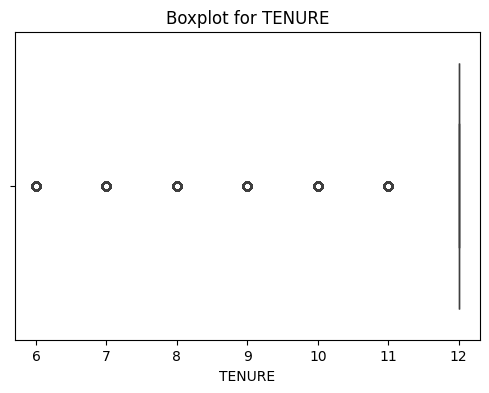

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# Upload the file
uploaded = files.upload()

# Get the uploaded filename
file_path = list(uploaded.keys())[0]
print("Using file:", file_path)

# Load the dataset
data = pd.read_csv(file_path)

# 1. Identify numeric vs categorical features
numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = data.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

# 2. Check distributions of numeric features (min, max, mean, std, skewness)
numeric_summary = data[numeric_features].describe().transpose()
numeric_summary['skewness'] = data[numeric_features].skew()

print("\nNumeric Features Distribution:")
print(numeric_summary)

# 3. Check counts of categories for categorical features
if categorical_features:
    for feature in categorical_features:
        print(f"\nCounts for categorical feature {feature}:")
        print(data[feature].value_counts())

# 4. Identify missing or unknown values
missing_values = data.isnull().sum()
print("\nMissing values per feature:")
print(missing_values[missing_values > 0])

# 5. Handle missing values for numeric columns (fill with median)
# Ensure only numeric columns are filled with the median
data[numeric_features] = data[numeric_features].fillna(data[numeric_features].median())

# 6. Look for correlations between numeric features
correlation_matrix = data[numeric_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# 7. Identify outliers that may affect clustering (using boxplots)
for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[feature])
    plt.title(f"Boxplot for {feature}")
    plt.show()

## 2. Data Preparation

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CC GENERAL.csv to CC GENERAL (3).csv


In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import files

# Upload the file
uploaded = files.upload()

# Get the uploaded filename
file_path = list(uploaded.keys())[0]
print("Using file:", file_path)

# Load the dataset
data = pd.read_csv(file_path)

# 1. Drop irrelevant columns (CUST_ID is an identifier, so we drop it)
data_cleaned = data.drop(columns=['CUST_ID'])

# 2. Check for missing values
missing_values = data_cleaned.isnull().sum()
print("Missing values in each column:\n", missing_values)

# 3. Handle missing values
# Fill missing values with the median of each column
data_cleaned = data_cleaned.fillna(data_cleaned.median())

# 4. Scale numeric features (important for distance-based algorithms like DBSCAN)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_cleaned)

# 5. Ensure all features are numeric (this is already handled above)

# Convert the scaled data back to a DataFrame
data_scaled = pd.DataFrame(scaled_data, columns=data_cleaned.columns)

# Display the prepared data (first 5 rows)
print("Prepared Data (first 5 rows):")
print(data_scaled.head())

Saving CC GENERAL.csv to CC GENERAL (4).csv
Using file: CC GENERAL (4).csv
Missing values in each column:
 BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64
Prepared Data (first 5 rows):
    BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0 -0.731989          -0.249434  -0.424900         -0.356934   
1  0.786961           0.134325  -0.469552   

## 3. Apply DBSCAN




DBSCAN Clustering Results:
cluster
-1     6624
 0     1951
 10      60
 2       34
 15      30
 14      23
 7       23
 8       14
 6       13
 3       11
 29      10
 5        9
 21       9
 26       8
 1        8
 12       8
 9        8
 19       7
 17       7
 27       7
 11       7
 23       6
 4        6
 13       6
 31       5
 30       5
 25       5
 18       5
 16       5
 35       5
 28       5
 24       5
 20       5
 22       5
 34       4
 32       4
 33       3
Name: count, dtype: int64


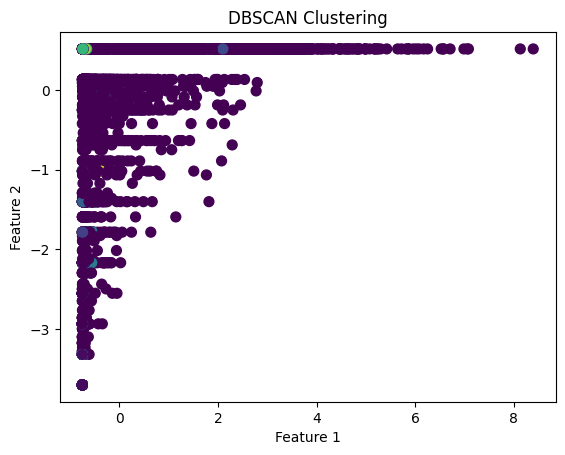

In [ ]:
# Import necessary libraries
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Apply DBSCAN
# Define the parameters: eps and min_samples
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Fit the DBSCAN model
data_scaled['cluster'] = dbscan.fit_predict(data_scaled)

# Check the resulting clusters
print("DBSCAN Clustering Results:")
print(data_scaled['cluster'].value_counts())

# Visualize the clusters (if the data has 2D or 3D features)
plt.scatter(data_scaled.iloc[:, 0], data_scaled.iloc[:, 1], c=data_scaled['cluster'], cmap='viridis', s=50)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 4. Evaluate the Clustering

In [ ]:
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np

# Evaluate the clustering using silhouette score
# The silhouette score ranges from -1 to +1, where +1 means points are well clustered, and -1 means they are misclassified
sil_score = silhouette_score(data_scaled.drop(columns=['cluster']), data_scaled['cluster'])
print("Silhouette Score:", sil_score)

# If you have true labels (e.g., ground truth clustering), you can evaluate using ARI
# Adjusted Rand Index is only meaningful if you have ground truth labels (true clustering)
# true_labels = [your_true_labels]  # Replace this with actual true labels if available
# ari_score = adjusted_rand_score(true_labels, data_scaled['cluster'])
# print("Adjusted Rand Index (ARI):", ari_score)

# Number of clusters formed (including noise points)
num_clusters = len(set(data_scaled['cluster'])) - (1 if -1 in data_scaled['cluster'].values else 0)  # Excluding noise (-1)
print(f"Number of Clusters (excluding noise): {num_clusters}")

# Number of noise points (points with cluster label -1)
num_noise_points = list(data_scaled['cluster']).count(-1)
print(f"Number of Noise Points: {num_noise_points}")

Silhouette Score: -0.4658992441861622
Number of Clusters (excluding noise): 36
Number of Noise Points: 6624
